In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
df=pd.read_csv('student_placement_cgpa_iq_dataset.csv')
df

,CGPA,IQ,PlacementStatus
0,6.87,126,1
1,9.75,91,1
2,8.66,141,1
3,7.99,87,0
4,5.78,100,0
...,...,...,...
995,5.46,104,0
996,9.59,87,1
997,5.68,137,1
998,9.75,95,1


In [39]:
df.head()

,CGPA,IQ,PlacementStatus
0,6.87,126,1
1,9.75,91,1
2,8.66,141,1
3,7.99,87,0
4,5.78,100,0


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CGPA             1000 non-null   float64
 1   IQ               1000 non-null   int64  
 2   PlacementStatus  1000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


In [41]:
df.shape

(1000, 3)

In [64]:
df['PlacementStatus'].value_counts

<bound method IndexOpsMixin.value_counts of 0      1
1      1
2      1
3      0
4      0
      ..
995    0
996    1
997    1
998    1
999    0
Name: PlacementStatus, Length: 1000, dtype: int64>

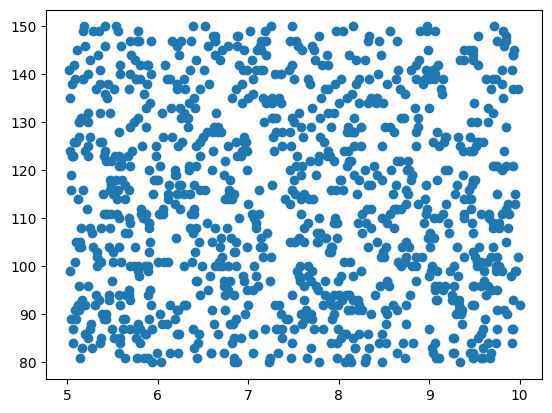

In [42]:
plt.scatter(df['CGPA'],df['IQ'])

In [43]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [44]:
X


,CGPA,IQ
0,6.87,126
1,9.75,91
2,8.66,141
3,7.99,87
4,5.78,100
...,...,...
995,5.46,104
996,9.59,87
997,5.68,137
998,9.75,95


In [45]:
y

0      1
1      1
2      1
3      0
4      0
      ..
995    0
996    1
997    1
998    1
999    0
Name: PlacementStatus, Length: 1000, dtype: int64

In [46]:
y.shape

(1000,)

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [49]:
X_train

,CGPA,IQ
878,5.14,81
336,9.28,85
478,9.85,129
613,5.41,123
239,5.89,94
...,...,...
726,5.70,100
206,5.51,101
0,6.87,126
616,5.31,92


In [50]:
y_train

878    0
336    1
478    1
613    0
239    0
      ..
726    0
206    0
0      1
616    0
186    1
Name: PlacementStatus, Length: 800, dtype: int64

In [51]:
X_test

,CGPA,IQ
957,5.23,130
367,9.53,130
283,5.47,132
90,5.60,122
518,9.94,145
...,...,...
435,8.50,102
32,5.33,103
983,5.38,101
973,6.07,101


In [52]:
y_test

957    1
367    1
283    1
90     1
518    1
      ..
435    1
32     0
983    0
973    0
522    1
Name: PlacementStatus, Length: 200, dtype: int64

In [53]:
scaler=StandardScaler()

In [54]:
X_train= scaler.fit_transform(X_train)

In [55]:
X_train

array([[-1.5855018 , -1.61967616],
       [ 1.24257983, -1.42056115],
       [ 1.63195339,  0.76970396],
       ...,
       [-0.4037189 ,  0.6203677 ],
       [-1.46937285, -1.07210988],
       [ 1.11278864,  0.22213768]], shape=(800, 2))

In [56]:
X_test= scaler.transform(X_test)
X_test

array([[-1.52402177e+00,  8.19482715e-01],
       [ 1.41335770e+00,  8.19482715e-01],
       [-1.36007501e+00,  9.19040220e-01],
       [-1.27127051e+00,  4.21252694e-01],
       [ 1.69343342e+00,  1.56616400e+00],
       [ 9.69335225e-01,  7.69703962e-01],
       [ 1.06497084e+00,  1.31727024e+00],
       [ 6.14117243e-01, -2.75649843e-01],
       [-1.09366152e+00, -6.73879864e-01],
       [ 6.96090623e-01, -1.37078240e+00],
       [-2.73927713e-01, -9.22773627e-01],
       [-1.20295936e+00,  1.66572151e+00],
       [ 1.68660231e+00, -1.32100365e+00],
       [ 1.70094765e-01,  1.61594276e+00],
       [-6.97456846e-01, -8.23216121e-01],
       [ 9.07855190e-01, -9.72552379e-01],
       [-5.67665661e-01,  1.51638525e+00],
       [ 3.20379296e-01, -4.74764853e-01],
       [-7.17950192e-01,  9.68818973e-01],
       [ 2.72561490e-01, -3.75207348e-01],
       [ 2.31574800e-01,  8.69261468e-01],
       [-8.27248032e-01, -7.65348321e-02],
       [-6.83111505e-04,  7.19925210e-01],
       [-1.

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
clf=LogisticRegression()

In [59]:
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [60]:
y_pred=clf.predict(X_test)

In [61]:
y_test

957    1
367    1
283    1
90     1
518    1
      ..
435    1
32     0
983    0
973    0
522    1
Name: PlacementStatus, Length: 200, dtype: int64

In [62]:
from sklearn.metrics import accuracy_score

In [63]:
accuracy_score(y_test,y_pred)

0.995

In [65]:
from sklearn.metrics import confusion_matrix, classification_report

In [66]:
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[ 55   0]
 [  1 144]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        55
           1       1.00      0.99      1.00       145

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [68]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

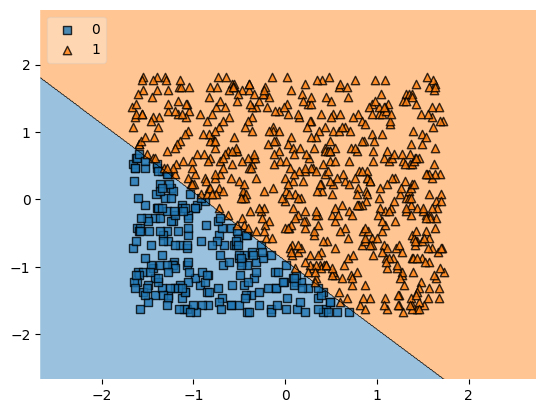

In [69]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [70]:
import pickle

In [71]:
pickle.dump(clf,open('model.pkl','wb'))